# MovieLens 20M - Extended MVP EDA

This notebook extends the MVP analysis with additional metrics and presentation-ready visuals.

Goals:
1. Validate data quality and coverage.
2. Quantify sparsity and popularity concentration.
3. Define practical swipe-label thresholds.
4. Inspect user/item behavior and temporal dynamics.
5. Surface cold-start and metadata signals for next-stage modeling.

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1) Load Data

In [4]:
def resolve_data_dir() -> Path:
    required_files = ('ratings.csv', 'movies.csv')
    candidate_suffixes = (
        Path('.'),
        Path('data'),
        Path('data/raw'),
        Path('backend/src/movie_recommender/services/recommender/data'),
        Path('backend/src/movie_recommender/services/recommender/data/raw'),
    )

    for root in (Path.cwd(), *Path.cwd().parents):
        for suffix in candidate_suffixes:
            candidate = (root / suffix).resolve()
            if all((candidate / name).exists() for name in required_files):
                return candidate

    raise FileNotFoundError(
        'Could not find ratings.csv and movies.csv from the current working directory. '
        'Expected them in the recommender data folder or a data/raw folder.'
    )


def load_optional_csv(data_dir: Path, filename: str, columns: list[str]) -> pd.DataFrame:
    path = data_dir / filename
    if path.exists():
        return pd.read_csv(path)

    print(f'{filename} not found in {data_dir}; using an empty DataFrame.')
    return pd.DataFrame(columns=columns)


DATA_DIR = resolve_data_dir()
ratings = pd.read_csv(DATA_DIR / 'ratings.csv')
movies = pd.read_csv(DATA_DIR / 'movies.csv')
tags = load_optional_csv(DATA_DIR, 'tags.csv', ['userId', 'movieId', 'tag', 'timestamp'])
links = load_optional_csv(DATA_DIR, 'links.csv', ['movieId', 'imdbId', 'tmdbId'])

print('Loaded from:', DATA_DIR)

tags.csv not found in C:\Users\diech\Chatbots\arrival-movie-recommender\backend\src\movie_recommender\services\recommender\data; using an empty DataFrame.
links.csv not found in C:\Users\diech\Chatbots\arrival-movie-recommender\backend\src\movie_recommender\services\recommender\data; using an empty DataFrame.
Loaded from: C:\Users\diech\Chatbots\arrival-movie-recommender\backend\src\movie_recommender\services\recommender\data


## 2) Data Health Snapshot
Basic checks to confirm size, missingness, and key ID coverage.

In [5]:
print('ratings shape:', ratings.shape)
print('movies shape :', movies.shape)
print('tags shape   :', tags.shape)
print('links shape  :', links.shape)

display(ratings.head(3))

ratings shape: (20000263, 4)
movies shape : (27278, 3)
tags shape   : (0, 4)
links shape  : (0, 3)


,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819


In [6]:
health = pd.DataFrame({
    'table': ['ratings', 'movies', 'tags', 'links'],
    'rows': [len(ratings), len(movies), len(tags), len(links)],
    'missing_cells': [ratings.isna().sum().sum(), movies.isna().sum().sum(), tags.isna().sum().sum(), links.isna().sum().sum()]
})
display(health)

,table,rows,missing_cells
0,ratings,20000263,0
1,movies,27278,0
2,tags,0,0
3,links,0,0


In [7]:
users = ratings['userId'].nunique()
rated_movies = ratings['movieId'].nunique()
catalog_movies = movies['movieId'].nunique()
ratings_without_movie_match = (~ratings['movieId'].isin(movies['movieId'])).sum()

print('Unique users             :', users)
print('Unique rated movies      :', rated_movies)
print('Movies in catalog         :', catalog_movies)
print('ratings->movies missing   :', int(ratings_without_movie_match))

Unique users             : 138493
Unique rated movies      : 26744
Movies in catalog         : 27278
ratings->movies missing   : 0


## 3) Rating Signal and Swipe Labels
We inspect the explicit rating distribution and candidate thresholds for implicit labels.

In [8]:
display(ratings['rating'].describe())
print('Like rate (>= 3.5):', round((ratings['rating'] >= 3.5).mean(), 4))
print('Like rate (>= 4.0):', round((ratings['rating'] >= 4.0).mean(), 4))
print('Dislike rate (<= 2.5):', round((ratings['rating'] <= 2.5).mean(), 4))

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Like rate (>= 3.5): 0.6098
Like rate (>= 4.0): 0.4998
Dislike rate (<= 2.5): 0.1757


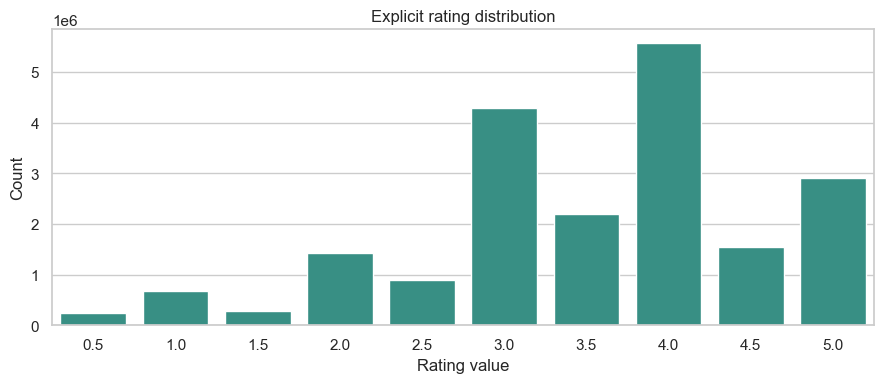

In [9]:
plt.figure(figsize=(9, 4))
sns.countplot(data=ratings, x='rating', color='#2a9d8f')
plt.title('Explicit rating distribution')
plt.xlabel('Rating value')
plt.ylabel('Count')
plt.tight_layout()

## 4) User and Item Activity Profiles
These metrics quantify heavy-tail behavior for users and movies.

In [10]:
user_counts = ratings.groupby('userId').size()
item_counts = ratings.groupby('movieId').size()

print('User activity quantiles')
display(user_counts.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]))

print('Item activity quantiles')
display(item_counts.quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]))

User activity quantiles


0.00      20.00
0.25      35.00
0.50      68.00
0.75     155.00
0.90     334.00
0.95     520.00
0.99    1113.08
1.00    9254.00
dtype: float64

Item activity quantiles


0.00        1.00
0.25        3.00
0.50       18.00
0.75      205.00
0.90     1305.70
0.95     3612.95
0.99    14388.69
1.00    67310.00
dtype: float64

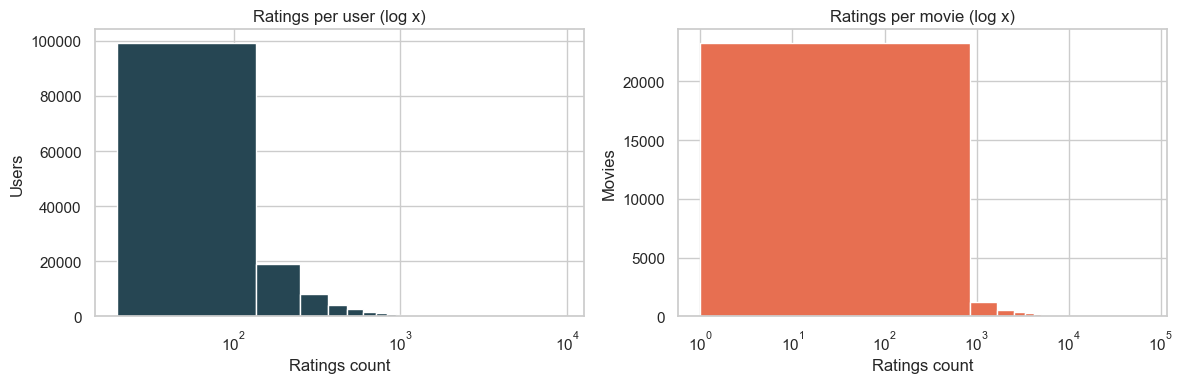

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_counts, bins=80, color='#264653')
axes[0].set_title('Ratings per user (log x)')
axes[0].set_xlabel('Ratings count')
axes[0].set_ylabel('Users')
axes[0].set_xscale('log')

axes[1].hist(item_counts, bins=80, color='#e76f51')
axes[1].set_title('Ratings per movie (log x)')
axes[1].set_xlabel('Ratings count')
axes[1].set_ylabel('Movies')
axes[1].set_xscale('log')

plt.tight_layout()

In [12]:
user_bucket = pd.cut(user_counts, bins=[0, 49, 199, 9999], labels=['20-49', '50-199', '200+'], include_lowest=True)
bucket_share = user_bucket.value_counts(normalize=True).sort_index()
display((bucket_share * 100).round(2).rename('percent_users'))

20-49     38.40
50-199    42.23
200+      19.37
Name: percent_users, dtype: float64

## 5) Sparsity, Concentration, and Popularity Bias
Sparsity and concentration summarize recommendation difficulty and baseline bias.

In [13]:
n_users = ratings['userId'].nunique()
n_items = ratings['movieId'].nunique()
n_interactions = len(ratings)

density = n_interactions / (n_users * n_items)
sparsity = 1 - density
print('Density :', round(density, 6))
print('Sparsity:', round(sparsity, 6))

Density : 0.0054
Sparsity: 0.9946


In [14]:
item_counts_sorted = item_counts.sort_values(ascending=False).values

for pct in [0.01, 0.05, 0.10, 0.20]:
    k = max(1, int(len(item_counts_sorted) * pct))
    share = item_counts_sorted[:k].sum() / n_interactions
    print(f'Top {int(pct*100)}% items capture: {share:.4f}')

Top 1% items capture: 0.3348
Top 5% items capture: 0.7141
Top 10% items capture: 0.8605
Top 20% items capture: 0.9538


In [15]:
def gini(x):
    arr = np.sort(np.asarray(x, dtype=float))
    n = arr.size
    if n == 0 or arr.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n

print('Item popularity Gini:', round(gini(item_counts), 4))
print('User activity Gini  :', round(gini(user_counts), 4))

Item popularity Gini: 0.9029
User activity Gini  : 0.5807


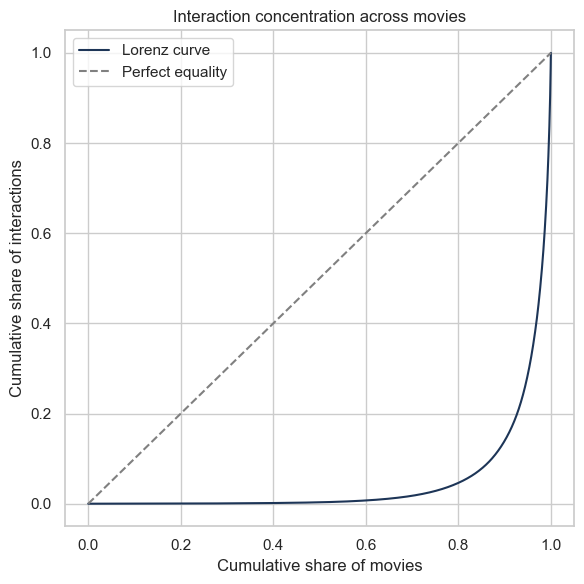

In [16]:
sorted_item_counts = np.sort(item_counts.values)
cum_items = np.arange(1, len(sorted_item_counts) + 1) / len(sorted_item_counts)
cum_interactions = np.cumsum(sorted_item_counts) / sorted_item_counts.sum()

plt.figure(figsize=(6, 6))
plt.plot(cum_items, cum_interactions, label='Lorenz curve', color='#1d3557')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect equality')
plt.title('Interaction concentration across movies')
plt.xlabel('Cumulative share of movies')
plt.ylabel('Cumulative share of interactions')
plt.legend()
plt.tight_layout()

## 6) Temporal Analysis
Temporal plots help validate time-based splitting and detect rating drift.

In [17]:
ratings['dt'] = pd.to_datetime(ratings['timestamp'], unit='s')
print('Min timestamp:', ratings['dt'].min())
print('Max timestamp:', ratings['dt'].max())

year_counts = ratings['dt'].dt.year.value_counts().sort_index()
display(year_counts.tail(10))

Min timestamp: 1995-01-09 11:46:44
Max timestamp: 2015-03-31 06:40:02


dt
2006    1171836
2007    1053430
2008    1158777
2009     930036
2010     903691
2011     766366
2012     731389
2013     599327
2014     562888
2015     283886
Name: count, dtype: int64

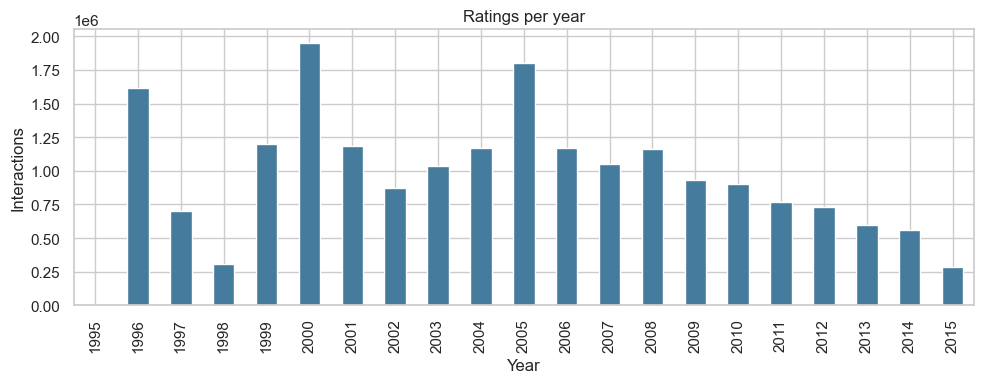

In [18]:
plt.figure(figsize=(10, 4))
year_counts.plot(kind='bar', color='#457b9d')
plt.title('Ratings per year')
plt.xlabel('Year')
plt.ylabel('Interactions')
plt.tight_layout()

C:\Users\diech\AppData\Local\Temp\ipykernel_17032\153318212.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = ratings.set_index('dt').resample('M').size()


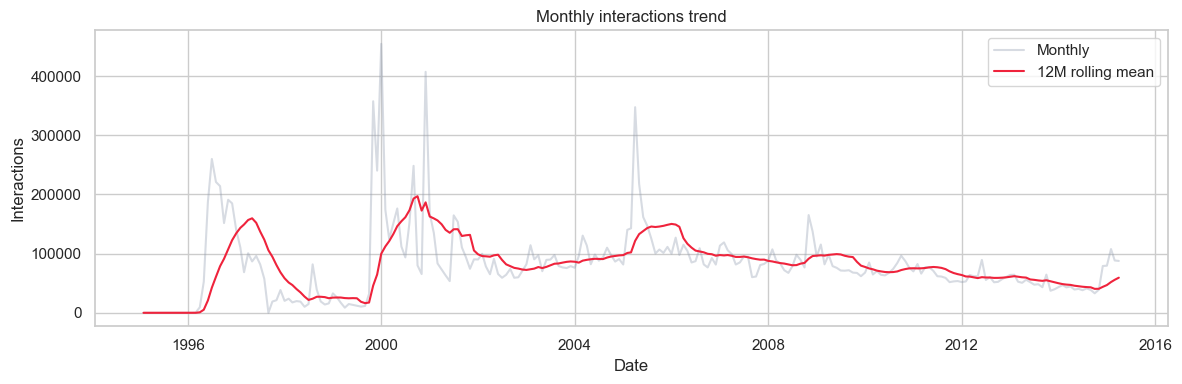

In [19]:
monthly = ratings.set_index('dt').resample('M').size()
rolling_12m = monthly.rolling(12, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, alpha=0.35, color='#8d99ae', label='Monthly')
plt.plot(rolling_12m.index, rolling_12m.values, color='#ef233c', label='12M rolling mean')
plt.title('Monthly interactions trend')
plt.xlabel('Date')
plt.ylabel('Interactions')
plt.legend()
plt.tight_layout()

C:\Users\diech\AppData\Local\Temp\ipykernel_17032\2661628326.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  monthly_rating = ratings.set_index('dt')['rating'].resample('Q').mean()


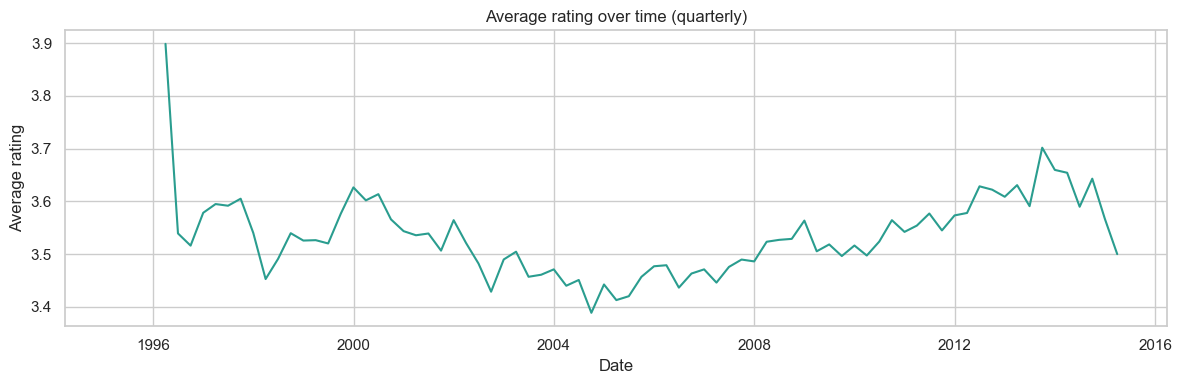

In [20]:
monthly_rating = ratings.set_index('dt')['rating'].resample('Q').mean()

plt.figure(figsize=(12, 4))
plt.plot(monthly_rating.index, monthly_rating.values, color='#2a9d8f')
plt.title('Average rating over time (quarterly)')
plt.xlabel('Date')
plt.ylabel('Average rating')
plt.tight_layout()

## 7) Movie Popularity and Quality
This section combines popularity (`n_ratings`) and mean rating to identify stable top titles.

In [21]:
movie_stats = ratings.groupby('movieId').agg(
    n_ratings=('rating', 'size'),
    avg_rating=('rating', 'mean')
).reset_index()
movie_stats = movie_stats.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
movie_stats.head()

,movieId,n_ratings,avg_rating,title,genres
0,1,49695,3.921240,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,22243,3.211977,Jumanji (1995),Adventure|Children|Fantasy
2,3,12735,3.151040,Grumpier Old Men (1995),Comedy|Romance
3,4,2756,2.861393,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,12161,3.064592,Father of the Bride Part II (1995),Comedy


In [22]:
popular_quality = movie_stats[movie_stats['n_ratings'] >= 500].sort_values('avg_rating', ascending=False).head(15)
display(popular_quality[['title', 'n_ratings', 'avg_rating']])

,title,n_ratings,avg_rating
315,"Shawshank Redemption, The (1994)",63366,4.446990
843,"Godfather, The (1972)",41355,4.364732
49,"Usual Suspects, The (1995)",47006,4.334372
523,Schindler's List (1993),50054,4.310175
1195,"Godfather: Part II, The (1974)",27398,4.275641
1935,Seven Samurai (Shichinin no samurai) (1954),11611,4.274180
887,Rear Window (1954),17449,4.271334
7356,Band of Brothers (2001),4305,4.263182
895,Casablanca (1942),24349,4.258327
905,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),6525,4.256935


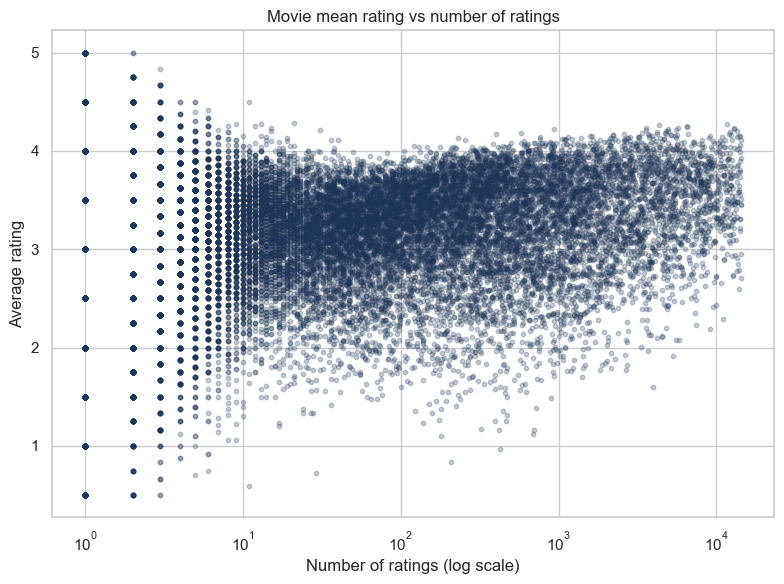

In [23]:
sample_for_plot = movie_stats[movie_stats['n_ratings'] <= movie_stats['n_ratings'].quantile(0.99)]

plt.figure(figsize=(8, 6))
plt.scatter(sample_for_plot['n_ratings'], sample_for_plot['avg_rating'], alpha=0.25, s=10, color='#1d3557')
plt.xscale('log')
plt.title('Movie mean rating vs number of ratings')
plt.xlabel('Number of ratings (log scale)')
plt.ylabel('Average rating')
plt.tight_layout()

## 8) Genre Insights
We measure both catalog composition and interaction-weighted genre demand.

In [24]:
movie_genres = movies.assign(genre=movies['genres'].str.split('|')).explode('genre')
genre_catalog = movie_genres['genre'].value_counts().head(15)
display(genre_catalog)

genre
Drama          13344
Comedy          8374
Thriller        4178
Romance         4127
Action          3520
Crime           2939
Horror          2611
Documentary     2471
Adventure       2329
Sci-Fi          1743
Mystery         1514
Fantasy         1412
War             1194
Children        1139
Musical         1036
Name: count, dtype: int64

In [25]:
genre_interactions = ratings[['movieId']].merge(movie_genres[['movieId', 'genre']], on='movieId', how='left')
genre_demand = genre_interactions['genre'].value_counts().head(15)
display(genre_demand)

genre
Drama        8857853
Comedy       7502234
Action       5614208
Thriller     5313506
Adventure    4380351
Romance      3802002
Crime        3298335
Sci-Fi       3150141
Fantasy      2111403
Children     1669249
Mystery      1557282
Horror       1482737
Animation    1140476
War          1048618
Musical       870915
Name: count, dtype: int64

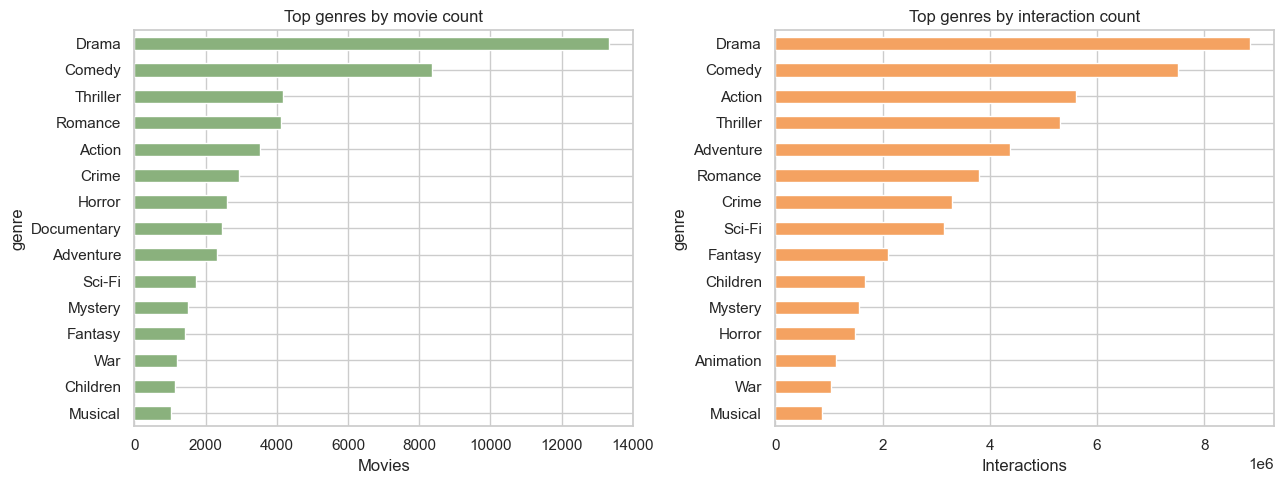

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
genre_catalog.sort_values().plot(kind='barh', ax=axes[0], color='#8ab17d')
axes[0].set_title('Top genres by movie count')
axes[0].set_xlabel('Movies')

genre_demand.sort_values().plot(kind='barh', ax=axes[1], color='#f4a261')
axes[1].set_title('Top genres by interaction count')
axes[1].set_xlabel('Interactions')

plt.tight_layout()

In [27]:
genre_avg = ratings[['movieId', 'rating']].merge(movie_genres[['movieId', 'genre']], on='movieId', how='left')
genre_avg = genre_avg.groupby('genre').agg(n=('rating', 'size'), avg_rating=('rating', 'mean')).reset_index()
genre_avg = genre_avg[genre_avg['n'] >= 5000].sort_values('avg_rating', ascending=False)
display(genre_avg.head(15))

,genre,n,avg_rating
10,Film-Noir,216689,3.965381
18,War,1048618,3.809531
7,Documentary,244619,3.739718
6,Crime,3298335,3.674528
8,Drama,8857853,3.674296
14,Mystery,1557282,3.663509
12,IMAX,492366,3.655946
3,Animation,1140476,3.617494
19,Western,423714,3.570498
13,Musical,870915,3.558091


## 9) Tag and Metadata Signals
Tags can provide side-information for retrieval or cold-start ranking.

In [28]:
if tags.empty:
    tags_clean = pd.DataFrame(columns=['userId', 'movieId', 'tag', 'timestamp', 'tag_norm'])
    print('tags.csv is not available in DATA_DIR; skipping tag analysis.')
else:
    tags_clean = tags.copy()
    tags_clean['tag_norm'] = tags_clean['tag'].str.lower().str.strip()

    print('Unique raw tags    :', tags['tag'].nunique())
    print('Unique normalized  :', tags_clean['tag_norm'].nunique())
    print('Users with tags    :', tags_clean['userId'].nunique())
    print('Movies with tags   :', tags_clean['movieId'].nunique())

tags.csv is not available in DATA_DIR; skipping tag analysis.


In [29]:
top_tags = tags_clean['tag_norm'].value_counts().head(20)
if top_tags.empty:
    print('No tag data available to summarize.')
else:
    display(top_tags)

No tag data available to summarize.


In [30]:
if top_tags.empty:
    print('No tag plot generated because tags.csv is not available.')
else:
    plt.figure(figsize=(10, 6))
    top_tags.sort_values().plot(kind='barh', color='#6d597a')
    plt.title('Most frequent tags')
    plt.xlabel('Count')
    plt.ylabel('Tag')
    plt.tight_layout()

No tag plot generated because tags.csv is not available.


## 10) Cold-Start and Practical Modeling Summary
Final summary metrics useful for a modeling handoff.

In [31]:
cold_metrics = {
    'movies_with_<=2_ratings': int((item_counts <= 2).sum()),
    'movies_with_<=5_ratings': int((item_counts <= 5).sum()),
    'movies_with_<=10_ratings': int((item_counts <= 10).sum()),
    'pct_movies_<=5': round((item_counts <= 5).mean(), 4),
    'pct_movies_<=10': round((item_counts <= 10).mean(), 4),
}
display(pd.Series(cold_metrics))

movies_with_<=2_ratings      6015.0000
movies_with_<=5_ratings      9225.0000
movies_with_<=10_ratings    11665.0000
pct_movies_<=5                  0.3449
pct_movies_<=10                 0.4362
dtype: float64